Imports

In [57]:
import sys
sys.path.append('imports')

%load_ext autoreload
%autoreload 2
import pickle as pkl
import numpy as np
import json
from os.path import sep
import cv2
from glob import glob
import matplotlib
import matplotlib.pyplot as plt
import select_files
import scienceplots
from scipy.interpolate import interp1d
from generate_training import modelist
import power_length_analysis
import Meta_classifier
import socket
from physt import h2
import pandas as pd
import phase_analysis_complete
import tqdm


plt.style.use(['science', 'ieee', 'no-latex'])

plt.rcParams.update({
    'figure.figsize': [7.2, 7.2],
    'font.size': 12,
    'figure.dpi': 100,
    'savefig.dpi': 300
})

if socket.gethostname() == 'ph-photonbec5':
    sys_path = r'D:/Data/2024'
if socket.gethostname() == 'r018104':
    sys_path = r'C:\Users\natak\OneDrive - Imperial College London\Documents\University\Year 4\MSci Project-r018104\All_data\202408'
else:
    print(r'C:\Users\Pouis\OneDrive - Imperial College London\PBEC\Data')
    raise Exception('unrecognised computer')


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Open and format data

In [58]:
# t_stamps = ['20240731_152730', '20240731_155505']
t_chunks = [['20240814_172304', '20240814_213106']
]

image_dir = sys_path
#Make new folder or everything will be deleted
crop_dir = sys_path + r'\Cropped_Images\15_08_crop'
files, metas = select_files.open_img_files(t_chunks, image_dir)
print(len(files))

1280


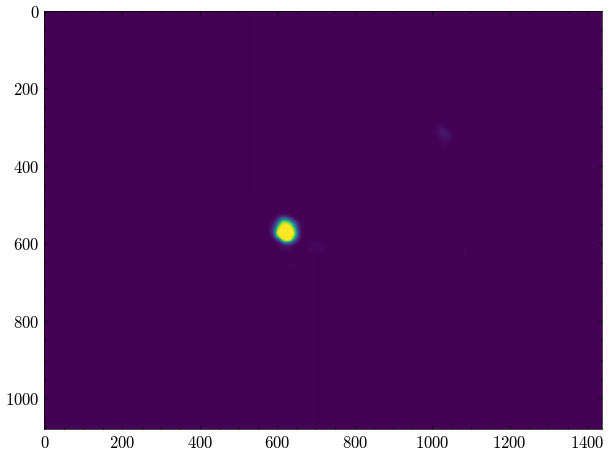

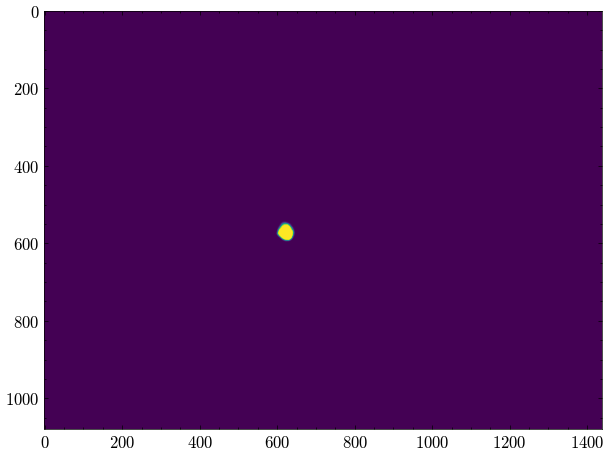

completed crop


In [59]:
bec_file = sys_path + r'\20240814\pbec_20240814_182134_4.0_0.1713684210526316_948.76220703125_7.0_nathans_dungeon_cavity_NA1_.png'
power_length_analysis.bec_crop_centre(bec_file, files, [170, 170], crop_dir)

In [60]:
print(len(files))
files = np.array(glob(crop_dir + sep + '*.png'))
print(len(files))
data = power_length_analysis.data_from_metas(metas, files)

1280
1280


# Select Stimulated Files
Various methods to select. Recommend stimulated_exp. Choose a maximum camera exposure time, everything below is stimulated emission. Can also choose by ND filter

In [62]:
# stim_mask = select_files.select_stimulated_nd(data)
# stim_mask = select_files.select_stimulated_exp(data, 5)
stim_mask = select_files.select_stimulated_exp_from_filename(data['file'], 1000)
print(np.sum(stim_mask))


259


# PCA Fits
Fit wavelengths to the PCA. Not good to use if lock drifts a lot. 

20240814213106
950.9727172851562


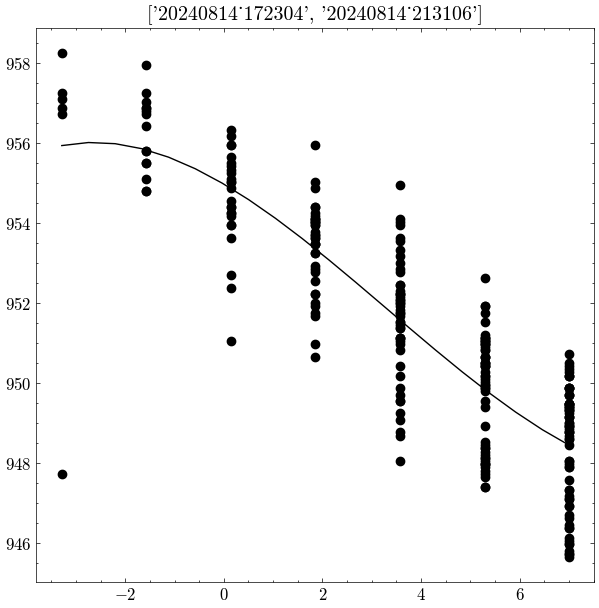

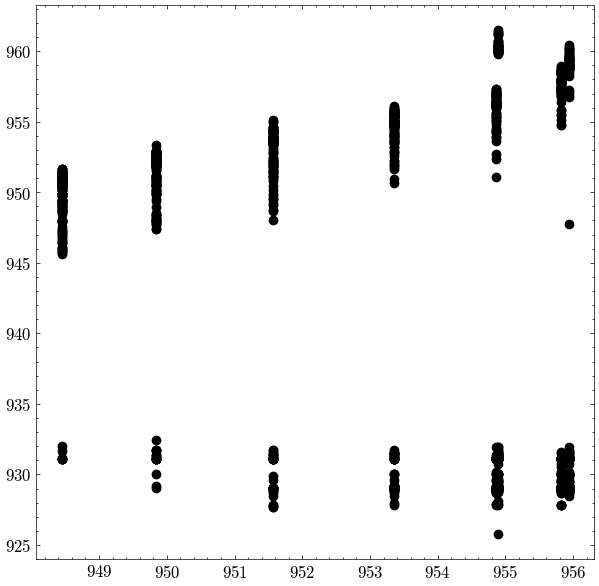

In [63]:


# Fit PCA values to cavity length
if 'pca' not in data.keys():
    print('!')
    png_data = power_length_analysis.data_dict(files)
    data.update({'pca': png_data['pca']})

pca_length = []

for i in t_chunks:
    # Creates mask for stimulated emission and each time cavity is locked
    mint = int(i[0].split('_')[0] + i[0].split('_')[1])
    maxt = int(i[1].split('_')[0] + i[1].split('_')[1])
    print(maxt)
    tmask = (mint <= data['t']) & (data['t'] <= maxt)
    mask = tmask & stim_mask

    # plt.scatter(data['cavity_length'][mask], data['power'][mask])
    # plt.show()

    mean_length = np.median(data['cavity_length'][mask])
    print(mean_length)
    length_mask = (mean_length - 10 <= data['cavity_length']) & (data['cavity_length'] <= mean_length + 10)
    mask = tmask & stim_mask & length_mask

    plt.scatter(data['pca'][mask], data['cavity_length'][mask])
    # plt.show()
    # fits pca values to cavity length
    _, fit = power_length_analysis.fit_pca(data['cavity_length'][mask], data['pca'][mask])
    pca_length += list(fit(data['pca'][tmask]))

    x = np.linspace(min(data['pca'][mask]), max(data['pca'][mask]), 20)
    plt.plot(x, fit(x))
    plt.title(i)
    plt.show()

data.update({'pca_length': np.array(pca_length)})

plt.scatter(data['pca_length'], data['cavity_length'])
plt.show()

# Choose Displacement

(Only use if applicable)

In [66]:
#Choose displacement
print(np.unique(data['position']))
positions = np.unique(data['position'])

pos_mask = select_files.select_position(data, positions[-4])

#combine the masks
mask = stim_mask & pos_mask
print(np.sum(mask))


[      0.  428571.  857142. 1285714. 1714285. 2142857. 2571428. 3000000.]
15


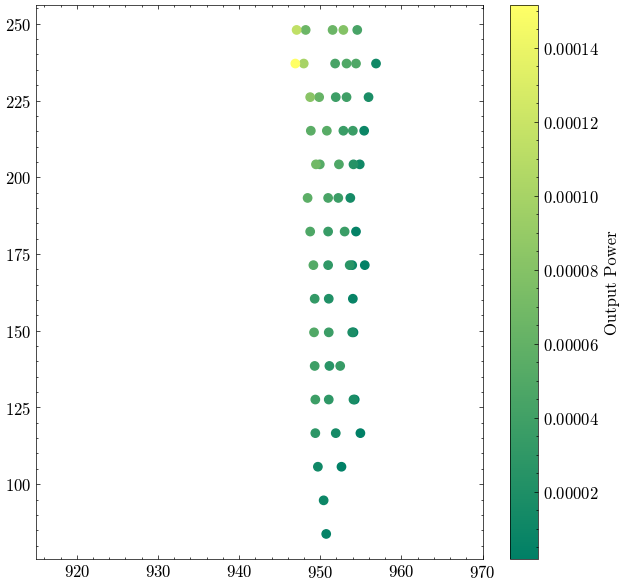

In [ ]:



fig, ax = plt.subplots(1, 1)
# Thermal cloud histogram
# power_length_analysis.plot_2dhist(
#     data['cavity_length'][~stim_mask],
#     data['power'][~stim_mask],
#     [910,970], [0,120],
#     'grey', 30, fig = fig, ax = ax, alpha = 1
# )

# # Stimulated emission histogram
# power_length_analysis.plot_2dhist(
#     data['cavity_length'][stim_mask],
#     data['power'][stim_mask],
#     [910,970], [0,120],
#     'orchid', 30, fig = fig, ax = ax, alpha= 1
# )

# print(data['pca_length'][stim_mask])

# Scattered points



scat = ax.scatter(data['cavity_length'][mask], data['power'][mask], c=data['meter_reading'][mask],
                  cmap='summer', label='Above Threshold')
#ax.scatter(data['cavity_length'][~stim_mask], data['power'][~stim_mask], color='black', label='Below Threshold')
ax.set_xlim([915, 970])
cbar = fig.colorbar(scat, ax=ax, label='Output Power')
plt.show()



# Interactive Plot
Colours are random

In [ ]:
#
#power_length_analysis.interactive_scatter(data['cavity_length'], data['power'], data['file'], labels_data = np.random.randint(0, 5, size=(len(data['pca_length'][stim_mask]))))

labels = np.ones(len(data['power']))
labels[stim_mask] = 0
labels[-1] = 2

#If only showing stim mask:
labels = np.random.randint(0, 5, len(data['power']))

power_length_analysis.interactive_scatter(data['cavity_length'][stim_mask], data['power'][stim_mask], data['file'][stim_mask], labels_data=labels[stim_mask])

# Binned plot
Use this to test out the best bin count. This uses the physt module, and tries to make bins with the same number of points per bin. Don't increase the bin count too much.


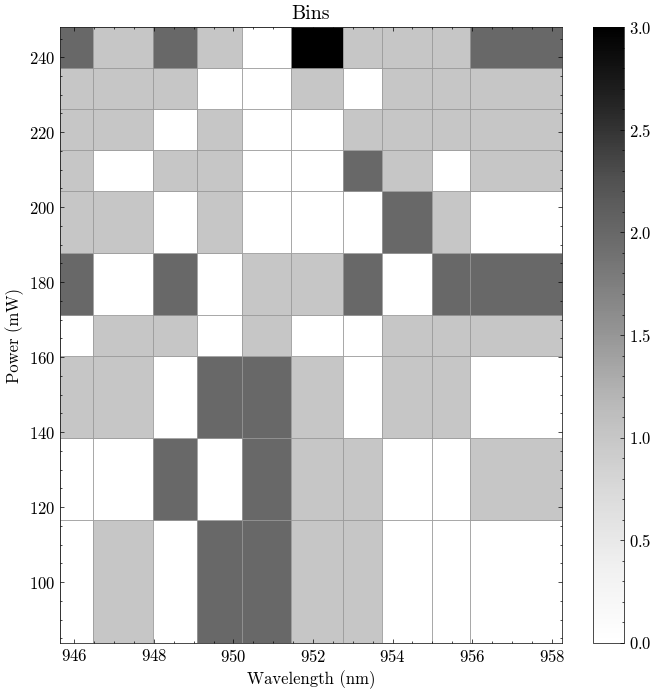

In [ ]:
bin_count = [10, 10]

histogram = h2(data['cavity_length'][stim_mask], data['power'][stim_mask], 'quantile', bin_count = bin_count, name = 'Bins', axis_names=['Wavelength (nm)', 'Power (mW)'])
histogram.plot()
bins = histogram.numpy_bins #Get bins to use in numpy - Use later!


#More accurate binning when including data under threshold - may break if pca length isn't very good though
# histogram = h2(data['cavity_length'], data['power'], 'quantile', bin_count = bin_count, name = 'Bins', axis_names=['Wavelength (nm)', 'Power (mW)'])
# histogram.plot()
# bins = histogram.numpy_bins #Get bins to use in numpy - Use later!

# Basic Clustering

Kmeans

In [ ]:
# Kmeans clustering on images
cluster_labels, _ = Meta_classifier.Kmeans_no_CNN(data['file'][stim_mask], 2)

# Plots each cluster
fig, ax, _, _ = power_length_analysis.all_cluster_plot(
    np.amax(cluster_labels), cluster_labels,
    data['pca_length'][stim_mask], data['power'][stim_mask],
    'tab20b', 8, [920, 960], [0, 120], 8
)



ValueError: n_components=100 must be between 0 and min(n_samples, n_features)=82 with svd_solver='full'

Fuzzy CMeans

In [ ]:
fuzzy_label, alpha, mem_mat = Meta_classifier.quick_fcmeans(data['flat_image'][stim_mask], 2, 1.5, return_matrix=True)

Text(0.02, 0.5, 'Power (mW)')

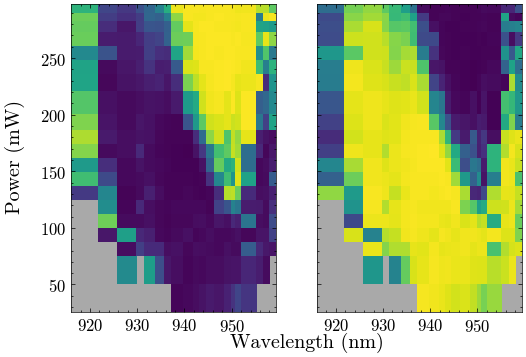

In [ ]:
#num plots, num columns, num rows
fig, axes, gs = power_length_analysis.grid_plot(2, 2, 1, 0.5, 0.5)

for i, col in enumerate(mem_mat):
    # power_length_analysis.plot_2dhist(
    #     data['pca_length'][~stim_mask],
    #     data['power'][~stim_mask],
    #     [920, 960], [0, 240],
    #     'grey', 15, fig=fig, ax=axes[i], alpha=1
    # )

    power_length_analysis.plot_2d_stat_hist(
        data['pca_length'][stim_mask],
        data['power'][stim_mask],
        col,
        [920, 960], [0, 120], bins=bins,
        cmap='viridis', fig=fig, ax=axes[i], facecolor='darkgrey'
    )

fig.supxlabel('Wavelength (nm)')
fig.supylabel('Power (mW)')
plt.tight_layout()
plt.show()

In [ ]:
fuzzy_label[-1] = -1
power_length_analysis.interactive_scatter(data['pca_length'][stim_mask], data['power'][stim_mask],
                                          data['file'][stim_mask], labels_data=fuzzy_label)

# CNN

Make Predictions

In [ ]:
model_root = r'C:\Users\Pouis\Documents\Uni Shit\Masters\PhaseGit\Supervised-clustering-phase-pBEC\MultiMode Analysis\Models\020824_multi_'
# save_path = ''
# %matplotlib qt
feat_vectors = Meta_classifier.predeict_images_CNN(data['file'][stim_mask], root = model_root, phases = 1, sigm=[0.1,0.1])
outputs, preds = Meta_classifier.predict_full_output(data['file'][stim_mask], root = model_root, phases = 1, sigm= [0.1,0.1])

cnn_outs = {
    'feature_vectors': feat_vectors,
    'outputs': outputs,
    'predictions': preds
}

# with open(save_path, 'w') as f:
#     json.dump(f)


0it [00:00, ?it/s]C:\Users\Pouis\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torchvision\transforms\v2\_deprecated.py:41: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.
  warnings.warn(
294it [00:16, 18.21it/s]
0it [00:00, ?it/s]C:\Users\Pouis\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torchvision\transforms\v2\_deprecated.py:41: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.
  warnings.warn(
294it [00:26, 11.17it/s]


Confidence plot

[0]


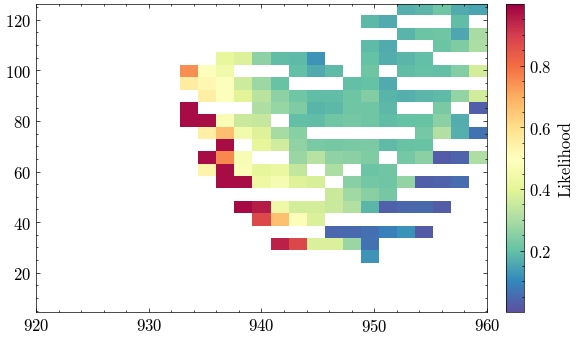

In [ ]:
#Scale for all colorbars
vs = [np.min(cnn_outs['outputs']), np.max(cnn_outs['outputs'])]

fig, axes, gs = power_length_analysis.grid_plot(
    nplots=1, ncols=1, nrows=1,
    wspace=0.5, hspace=0.5)

for i in range(cnn_outs['outputs'].shape[1]):
    mode_conf = cnn_outs['outputs'][:, i, 0]
    _, _, plot, stat = power_length_analysis.plot_2d_stat_hist(data['pca_length'][stim_mask],
                                                               data['power'][stim_mask],
                                                               mode_conf, [920, 960],
                                                               [min(data['power']), max(data['power'])], bins=bins,
                                                               cmap='Spectral_r',
                                                               fig=fig, ax=axes[i], vs=vs, ret_stat=True)

print(min(preds))

cbax = plt.subplot(gs[1])
plt.colorbar(plot, cbax, cmap='Spectral_r', label='Likelihood', )

# MULTIRUN!
This is so painful

  0%|          | 0/6 [00:00<?, ?it/s]

1550


 17%|█▋        | 1/6 [00:45<03:46, 45.35s/it]

510


c:\Users\natak\OneDrive - Imperial College London\Documents\University\Year 4\MSci Project-r018104\Phase diagram\Supervised-clustering-phase-pBEC\MultiMode Analysis\imports\phase_analysis_complete.py:75: RankWarning:

Polyfit may be poorly conditioned

c:\Users\natak\OneDrive - Imperial College London\Documents\University\Year 4\MSci Project-r018104\Phase diagram\Supervised-clustering-phase-pBEC\MultiMode Analysis\imports\phase_analysis_complete.py:75: RankWarning:

Polyfit may be poorly conditioned

 33%|███▎      | 2/6 [01:06<02:05, 31.26s/it]

...

c:\Users\natak\OneDrive - Imperial College London\Documents\University\Year 4\MSci Project-r018104\Phase diagram\Supervised-clustering-phase-pBEC\MultiMode Analysis\imports\phase_analysis_complete.py:75: RankWarning:

Polyfit may be poorly conditioned

 67%|██████▋   | 4/6 [01:45<00:47, 23.65s/it]

540


 83%|████████▎ | 5/6 [02:11<00:24, 24.42s/it]

720


c:\Users\natak\OneDrive - Imperial College London\Documents\University\Year 4\MSci Project-r018104\Phase diagram\Supervised-clustering-phase-pBEC\MultiMode Analysis\imports\phase_analysis_complete.py:75: RankWarning:

Polyfit may be poorly conditioned

100%|██████████| 6/6 [02:42<00:00, 27.09s/it]


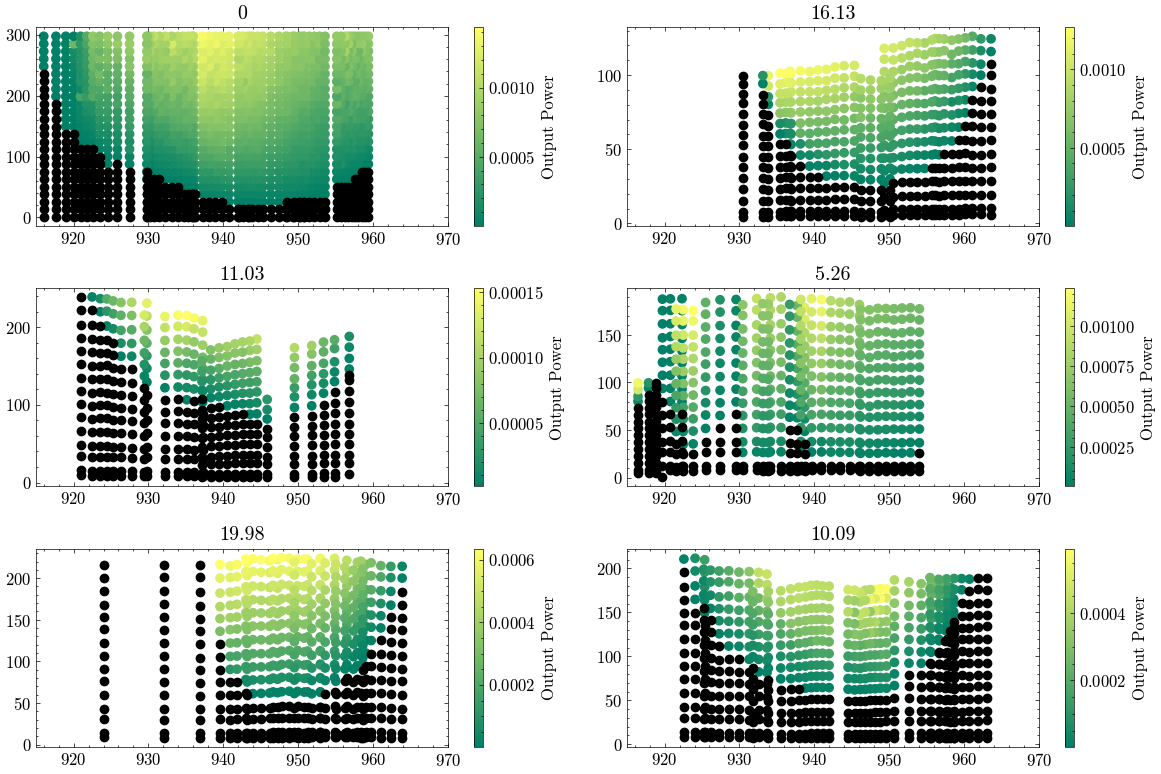

In [ ]:
%autoreload 2



#new setup complete, disp 2, disp 3, disp 4, disp 5, disp 6
#Displacements 0, 16.13, 11.03, 5.26, 19.98, 10.09

bec_paths = [r'\20240731\pbec_20240731_004630_438.0_0.08752745236408334_933.1723022460938_-2.0_.png',
             r'\20240801\pbec_20240801_195801_4.0_0.06916934232619047_941.4451293945312_-0.33333333333333304_.png',
             r'\20240802\pbec_20240802_134207_4.0_0.06997900204781667_929.1160888671875_-3.0_.png',
             r'\20240803\pbec_20240803_002215_4.0_0.07632187792076667_952.5397338867188_8.0_.png',
             r'\20240803\pbec_20240803_002215_4.0_0.07632187792076667_952.5397338867188_8.0_.png',
             r'\20240805\pbec_20240805_172704_4.0_0.08900762966666667_925.2636108398438_-2.5_.png']

t_chunks_chunks = [[
    ['20240730_124313', '20240730_135435'],
    ['20240730_141105', '20240730_151123'],
    ['20240730_151808', '20240730_161932'],
    ['20240730_163444', '20240730_172003'],
    ['20240730_175911', '20240730_184501'],
    ['20240730_215344', '20240730_230915'],
    ['20240730_232357', '20240731_005200'],
],
    [
        ['20240801_171523', '20240801_175414'],
        ['20240801_183108', '20240801_191359'],
        ['20240801_212439', '20240801_220751'],
        ['20240801_231338', '20240801_232843'],
        ['20240801_235340', '20240802_000734'],
        ['20240802_002049', '20240802_004200'],
    ],
    [
        ['20240802_123427', '20240802_131523'], ['20240802_133837', ' 20240802_140842'],
        ['20240802_155731', '20240802_163710'], ['20240802_165411', '20240802_172221']
    ],
    [
        ['20240802_174744', '20240802_181900'],
        ['20240802_184115', '20240802_191550'],
        ['20240802_195744', '20240802_202940'],
        ['20240802_204549', '20240802_212223'],
        ['20240801_235340', '20240802_000734'],
        ['20240802_220300', '20240802_224433'],
    ],
    [
        ['20240805_115346', '20240805_123034'],
        ['20240805_124130', '20240805_130656'],
        ['20240805_132757', '20240805_135826'],
        ['20240805_140736', '20240805_143803'],
        ['20240805_150101', '20240805_152650'],
        ['20240805_154030', '20240805_161608'],
    ],
    [['20240805_165517', '20240805_172704'], ['20240805_190016', '20240805_194134'],
     ['20240805_215133', '20240805_224241'], ['20240805_225747', '20240805_233845'],
     ['20240805_234747', '20240806_002829'], ['20240806_094407', '20240806_102520']]
]


#Make new folder or everything will be deleted
#crop_path = r'202408/Cropped_Images/22_07_disp_2_crop'
#bec_path = r'202408/20240801\pbec_20240801_195801_4.0_0.06916934232619047_941.4451293945312_-0.33333333333333304_.png'

titles = [0, 16.13, 11.03, 5.26, 19.98, 10.09]
fig = plt.figure(figsize=[12, 8])
for i in tqdm.tqdm(range(0, 6)):
    crop_path = r'/Cropped_Images/22_07_disp_{}_crop'.format(i+1)
    data, stim_mask = phase_analysis_complete.run_all(t_chunks_chunks[i], sys_path, crop_path, bec_paths[i])
    
    # Scattered points
    #fig, ax = plt.subplots(1, 1)
    ax = fig.add_subplot(3, 2, i+1)

    scat = ax.scatter(data['pca_length'][stim_mask], data['power'][stim_mask], c=data['meter_reading'][stim_mask],
                      cmap='summer', label='Above Threshold')
    ax.scatter(data['pca_length'][~stim_mask], data['power'][~stim_mask], color='black', label='Below Threshold')
    ax.set_xlim([915, 970])
    cbar = fig.colorbar(scat, ax=ax, label='Output Power')
    ax.set_title(titles[i])
    
    labels = np.ones(len(data['power']))
    labels[stim_mask] = 0
    labels[-1] = 2
    
    power_length_analysis.interactive_scatter(data['pca_length'], data['power'], data['file'], labels_data=labels)

plt.tight_layout()
plt.show()


# MULTIRUN WITH STAGE!

In [67]:
t_chunks = [['20240814_172304', '20240814_213106']
]

#change from sys_path
bec_path = r'\20240814\pbec_20240814_182134_4.0_0.1713684210526316_948.76220703125_7.0_nathans_dungeon_cavity_NA1_.png'

fig = plt.figure(figsize=[12, 12])

#Range is 0 to number of pump positions
for i in tqdm.tqdm(range(0, 8)):
    crop_path = r'/Cropped_Images/15_08_crop'
    data, stim_mask = phase_analysis_complete.run_all(t_chunks, sys_path, crop_path, bec_path, position_index=i)
    
    # Scattered points
    #fig, ax = plt.subplots(1, 1)
    ax = fig.add_subplot(4, 2, i+1)

    scat = ax.scatter(data['cavity_length'][stim_mask], data['power'][stim_mask], c=data['meter_reading'][stim_mask],
                      cmap='summer', label='Above Threshold')
    #ax.scatter(data['pca_length'][~stim_mask], data['power'][~stim_mask], color='black', label='Below Threshold')
    ax.set_xlim([915, 970])
    cbar = fig.colorbar(scat, ax=ax, label='Output Power')
    ax.set_title(str(i))
    
    labels = np.ones(len(data['power']))
    labels[stim_mask] = 0
    labels[-1] = 2
    
    #power_length_analysis.interactive_scatter(data['cavity_length'], data['power'], data['file'], labels_data=labels)

plt.tight_layout()
plt.show()

  0%|          | 0/8 [00:00<?, ?it/s]

1280
completed crop
